# Генератор пользовательских данных для подсчета клеток крови — HT_3

## Требования задания:
1. Изучить набор данных blood_cells
2. Выполнить нарезку изображений (фон и клетки в отдельные папки)
3. Реализовать генератор данных снимков клеток крови
4. Фон из патчей (из набора + искусственные)
5. Клетки из патчей + искусственные окружности
6. Применять seamless cloning для blending
7. Генератор возвращает: чистое изображение, зашумленное, количество клеток
8. Реализовать удаление шума: медианный, гаусса, билатериальный, нелокальные средние
9. Для 100 изображений: генерация, зашумление, удаление шума
10. Рассчитать SSIM, MSE, определить лучший алгоритм для каждого типа шума

## HT_3:
### Преобразование Фурье:
1. Преобразовать исходный генератор данных. Добавить возможность добавления периодического шума.
2. Удалить периодический шум при помощи преобразования Фурье.
3. Измерить показатели качества при помощи преобразования Фурье.

### Сжатие данных при помощи вейвлет-преобразования:
1. Исходное изображение в оттенках серого кодируется в текстовом файле попиксельной записью интенсивности.
   a. RLE: Каждое значимое значение хранится парой чисел: (количество нулей перед ним, само значение)
2. Реализовать вейвлет-преобразование Хаара.
3. Удалить высокочастотные составляющие с низкими детализирующими коэффициентами.
4. Закодировать данные при помощи RLE алгоритма.
5. Сохранить получившиеся данные.
6. Определить степень сжатия (среднюю для набора изображений). Отношение объема файла до/после сжатия.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from typing import Tuple, List
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
from torch.utils.data import Dataset
import itertools
from scipy import fftpack
import math

## 1. Загрузка и подготовка данных

In [2]:
DATA_DIR = 'BCCD Dataset with mask/train'
IMAGES_DIR = os.path.join(DATA_DIR, 'original')
MASKS_DIR = os.path.join(DATA_DIR, 'mask')

BACKGROUND_PATCHES_DIR = 'background_patches'
CELL_PATCHES_DIR = 'cell_patches'
os.makedirs(BACKGROUND_PATCHES_DIR, exist_ok=True)
os.makedirs(CELL_PATCHES_DIR, exist_ok=True)

In [3]:
def load_blood_cell_dataset(images_dir, masks_dir, max_images=1000):
    images = []
    masks = []
    
    for filename in os.listdir(images_dir):
        if len(images) >= max_images:
            break
            
        img_path = os.path.join(images_dir, filename)
        mask_path = os.path.join(masks_dir, filename)
        
        if os.path.exists(mask_path):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            if img is not None and mask is not None:
                images.append(img)
                masks.append(mask)
    
    return images, masks

In [4]:
def extract_patches(images, masks, patch_size=(128, 128), n_patches=100):
    background_patches = []
    cell_patches = []
    
    for img, mask in zip(images, masks):
        h, w = img.shape[:2]
        
        for _ in range(n_patches // 2):
            x = random.randint(0, w - patch_size[1])
            y = random.randint(0, h - patch_size[0])
            
            patch = img[y:y+patch_size[0], x:x+patch_size[1]]
            mask_patch = mask[y:y+patch_size[0], x:x+patch_size[1]]
            
            if np.count_nonzero(mask_patch) < patch_size[0] * patch_size[1] * 0.05:
                background_patches.append(patch)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            x, y, w_cell, h_cell = cv2.boundingRect(contour)
            
            if w_cell > 20 and h_cell > 20:
                pad = 10
                x1 = max(0, x - pad)
                y1 = max(0, y - pad)
                x2 = min(img.shape[1], x + w_cell + pad)
                y2 = min(img.shape[0], y + h_cell + pad)
                
                cell_patch = img[y1:y2, x1:x2]
                cell_mask = mask[y1:y2, x1:x2]
                
                cell_only = cv2.bitwise_and(cell_patch, cell_patch, mask=cell_mask)
                if cell_only.size > 0:
                    cell_patches.append(cell_only)
    
    return background_patches, cell_patches

In [5]:
def save_patches(background_patches, cell_patches, bg_dir, cell_dir, max_save=50):
    for i, patch in enumerate(background_patches[:max_save]):
        cv2.imwrite(os.path.join(bg_dir, f'bg_{i}.png'), patch)
    
    for i, patch in enumerate(cell_patches[:max_save]):
        cv2.imwrite(os.path.join(cell_dir, f'cell_{i}.png'), patch)
    
    print(f"Сохранено {len(background_patches)} патчей фона и {len(cell_patches)} патчей клеток")

In [6]:
try:
    images, masks = load_blood_cell_dataset(IMAGES_DIR, MASKS_DIR, 100)
    print(f"Загружено {len(images)} изображений")
    
    bg_patches, cell_patches = extract_patches(images, masks)
    save_patches(bg_patches, cell_patches, BACKGROUND_PATCHES_DIR, CELL_PATCHES_DIR)
    
except FileNotFoundError:
    print("Набор данных не найден. Используем синтетические данные.")
    bg_patches, cell_patches = [], []

Загружено 100 изображений
Сохранено 1147 патчей фона и 7106 патчей клеток


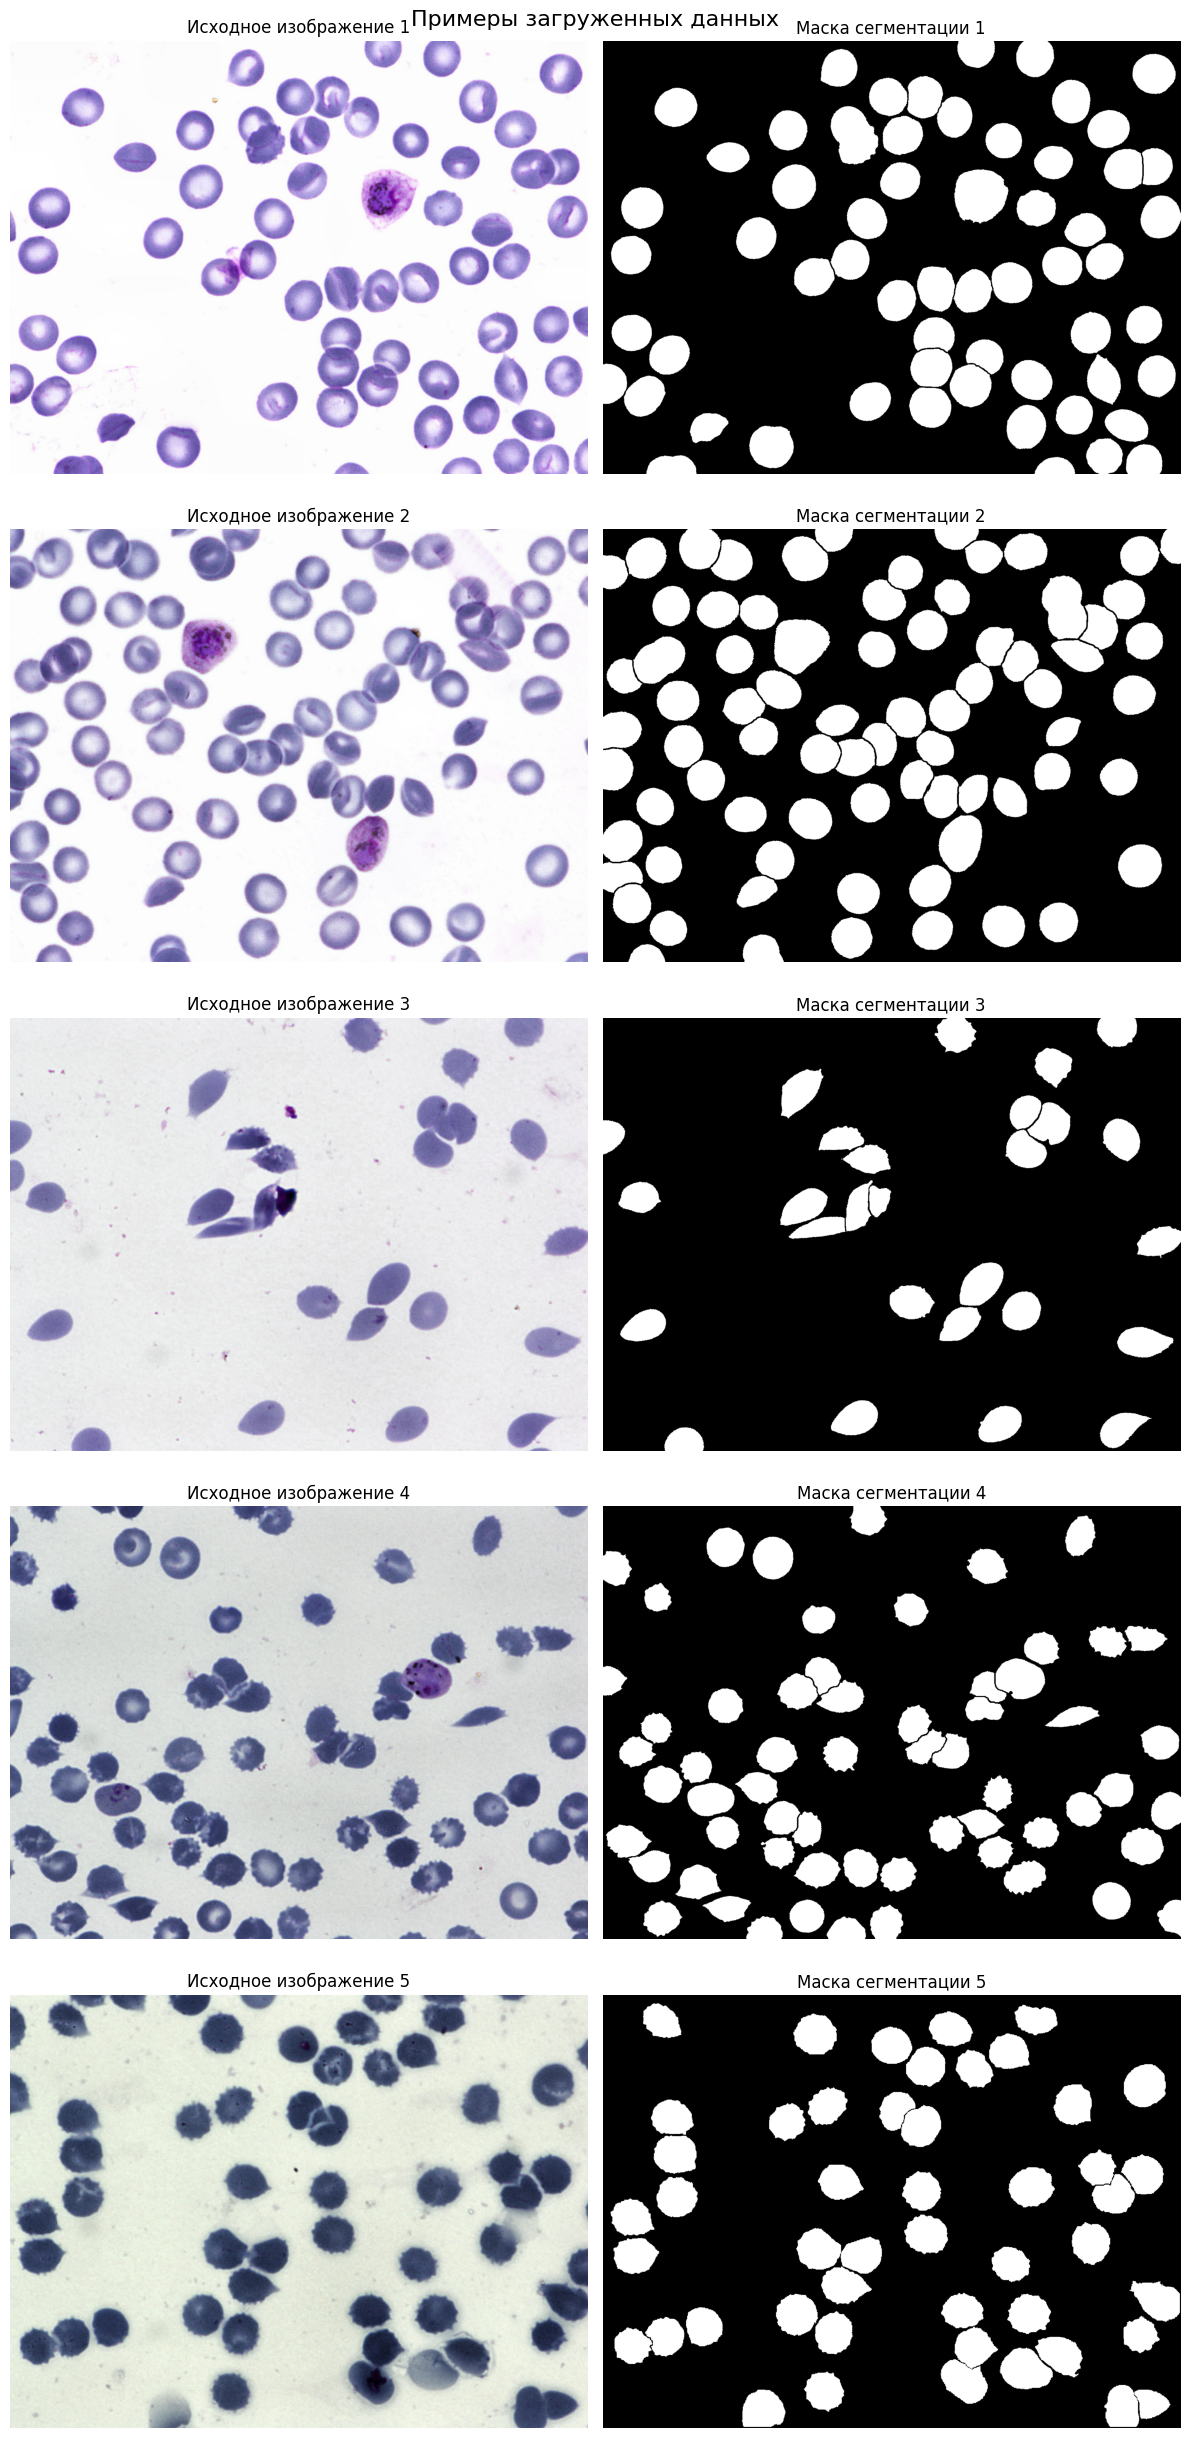

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(12, 25))
fig.suptitle("Примеры загруженных данных", fontsize=16)

for i in range(5):
    axes[i, 0].imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Исходное изображение {i+1}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(masks[i], cmap='gray')
    axes[i, 1].set_title(f"Маска сегментации {i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

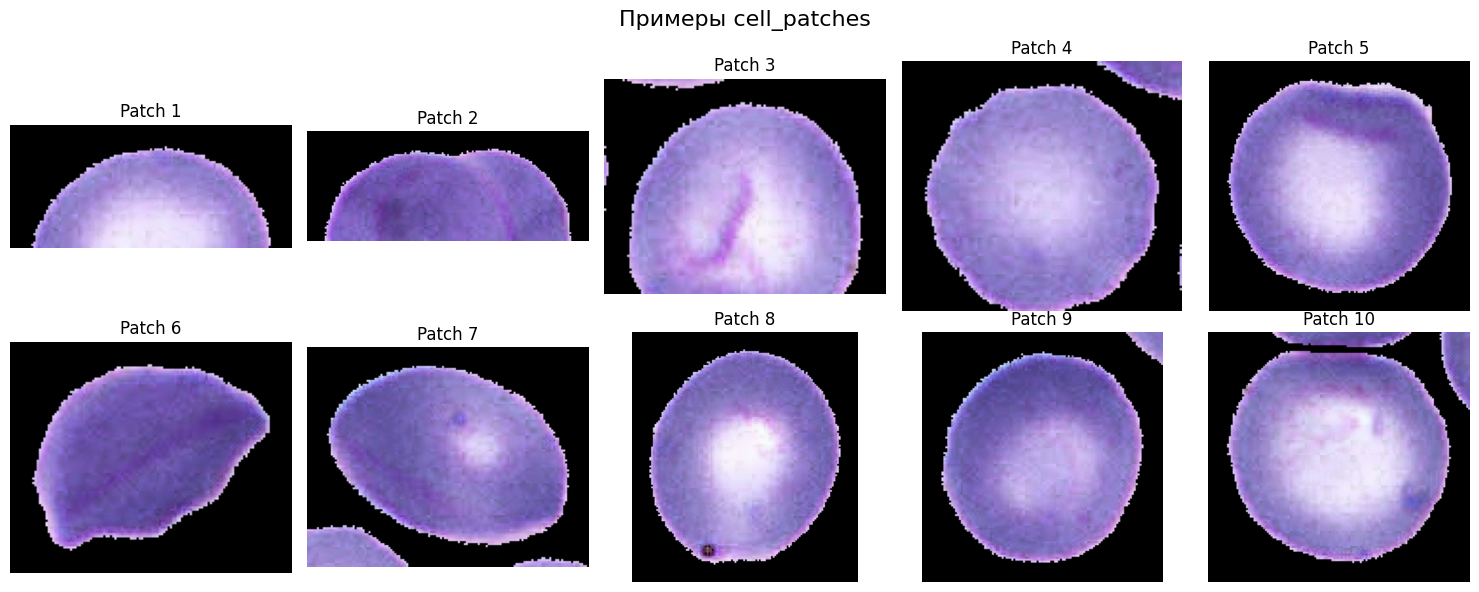

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры cell_patches", fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(cv2.cvtColor(cell_patches[i], cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f"Patch {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

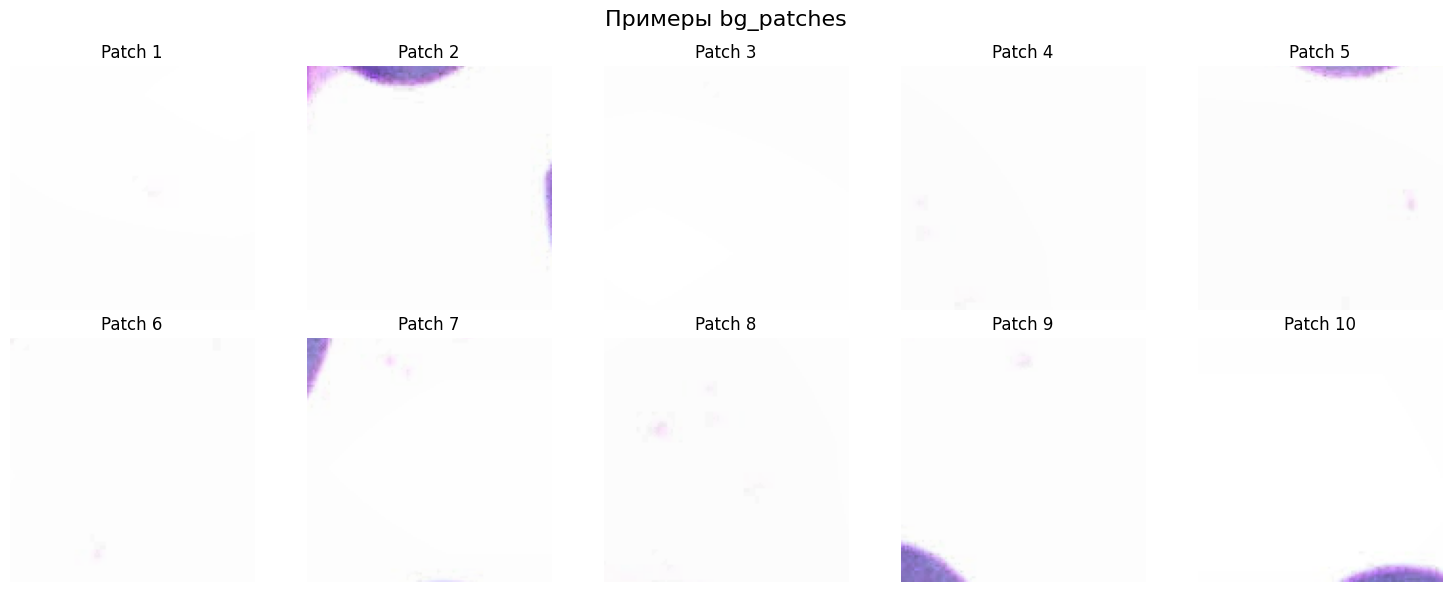

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры bg_patches", fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(cv2.cvtColor(bg_patches[i], cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f"Patch {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 2. Реализация Dataset класса

In [10]:
def add_periodic_noise(image, num_sinewaves=3, amplitude_range=(30, 80), 
                       frequency_range=(0.05, 0.3), angle_range=(0, 360)):
    h, w = image.shape[:2]
    noisy = image.astype(np.float32).copy()
    
    if len(noisy.shape) == 3:
        noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2GRAY).astype(np.float32)
    
    for _ in range(num_sinewaves):
        amplitude = np.random.uniform(*amplitude_range)
        freq = np.random.uniform(*frequency_range)
        angle = np.random.uniform(*angle_range)
        phase = np.random.uniform(0, 2*np.pi)
        
        x = np.arange(w)
        y = np.arange(h)
        X, Y = np.meshgrid(x, y)
        
        x_rot = X * np.cos(np.radians(angle)) + Y * np.sin(np.radians(angle))
        noise_pattern = amplitude * np.sin(2 * np.pi * freq * x_rot + phase)
        noisy = noisy + noise_pattern
    
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy


def fourier_denoise_periodic(image, notch_radius=15, show_spectrum=False):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    dft = cv2.dft(np.float32(gray), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
    
    if show_spectrum:
        plt.figure(figsize=(5,5))
        plt.imshow(magnitude_spectrum, cmap='gray')
        plt.title('Magnitude Spectrum')
        plt.axis('off')
        plt.show()
    
    h, w = gray.shape
    mask = np.ones((h, w, 2), np.uint8)
    center_y, center_x = h // 2, w // 2
    
    spectrum_norm = magnitude_spectrum / (magnitude_spectrum.max() + 1e-8)
    threshold = 0.7
    peaks = []
    
    for y in range(h):
        for x in range(w):
            if spectrum_norm[y, x] > threshold:
                dist_from_center = np.sqrt((x-center_x)**2 + (y-center_y)**2)
                if dist_from_center > 30:
                    peaks.append((y, x))
    
    for py, px in peaks:
        cv2.circle(mask, (px, py), notch_radius, (0, 0), -1)
        sym_x, sym_y = 2*center_x - px, 2*center_y - py
        if 0 <= sym_x < w and 0 <= sym_y < h:
            cv2.circle(mask, (sym_x, sym_y), notch_radius, (0, 0), -1)
    
    dft_shift_filtered = dft_shift * mask
    dft_ishift = np.fft.ifftshift(dft_shift_filtered)
    img_back = cv2.idft(dft_ishift)
    img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
    
    denoised = np.clip(img_back, 0, 255).astype(np.uint8)
    return denoised, magnitude_spectrum, mask[:,:,0]

In [11]:
class BloodCellsDataset(Dataset):
    def __init__(
        self,
        img_size: Tuple[int, int] = (600, 800),
        dataset_size: int = 100,
        bg_patches: List = None,
        cell_patches: List = None,
        p_background_solid: float = 0.3,
        p_cell_artificial: float = 0.3,
        min_cells_count: int = 40,
        max_cells_count: int = 100,
        min_cell_coverage: float = 0.25,
        gauss_noise_params_ranges: Tuple = ((0, 50), (0, 50)),
        uniform_noise_params_ranges: Tuple = ((-100, 100), (-100, 100)),
        p_gauss_noise_choice: float = 0.5,
        p_periodic_noise: float = 0.2,
    ):

        self.img_size = img_size
        self.dataset_size = dataset_size
        self.bg_patches = bg_patches if bg_patches else []
        self.cell_patches = cell_patches if cell_patches else []
        self.p_background_solid = p_background_solid
        self.p_cell_artificial = p_cell_artificial
        self.min_cells_count = min_cells_count
        self.max_cells_count = max_cells_count
        self.min_cell_coverage = min_cell_coverage
        self.gauss_noise_params_ranges = gauss_noise_params_ranges
        self.uniform_noise_params_ranges = uniform_noise_params_ranges
        self.p_gauss_noise_choice = p_gauss_noise_choice
        self.p_periodic_noise = p_periodic_noise
    
    def __len__(self):
        return self.dataset_size
    
    def __getitem__(self, item):
        cells_count = random.randint(self.min_cells_count, self.max_cells_count)
        
        clean_img = self._select_background()

        cells_img = np.zeros((clean_img.shape[0], clean_img.shape[1], 3), dtype=np.uint8)
        temp_img = np.zeros((clean_img.shape[0], clean_img.shape[1], 3), dtype=np.uint8)
        temp_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), dtype=np.uint8)

        cells_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), dtype=np.uint8)
        temp_mask = cells_mask.copy()
        cells_img = np.zeros_like(clean_img)
        temp_img = np.zeros_like(cells_img)
        
        actual_cells_count = 0

        for i in range(cells_count):
            for _max_attempts in range(999):
                temp_mask.fill(0)
                temp_img.fill(0)
 
                x = random.randint(0, clean_img.shape[1] - 1)
                y = random.randint(0, clean_img.shape[0] - 1)
                
                use_artificial_cell = random.random() < self.p_cell_artificial
                
                if use_artificial_cell and len(self.cell_patches) > 0:
                    patch = random.choice(self.cell_patches)
                    rad = random.randint(max(3, patch.shape[0]//8), patch.shape[0]//4)
                    color = self._get_cell_color()
                    
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    temp_img = temp_img.astype(np.uint8)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=color, thickness=-1)
                elif len(self.cell_patches) > 0:
                    cell_patch = random.choice(self.cell_patches)
                    cell_patch = cv2.resize(cell_patch, (random.randint(20, 50), random.randint(20, 50)))
                    
                    h_patch, w_patch = cell_patch.shape[:2]
                    x1 = max(0, min(x - w_patch//2, clean_img.shape[1] - w_patch))
                    y1 = max(0, min(y - h_patch//2, clean_img.shape[0] - h_patch))
                    
                    temp_mask[y1:y1+h_patch, x1:x1+w_patch] = 255
                    temp_img[y1:y1+h_patch, x1:x1+w_patch] = cell_patch
                else:
                    rad = random.randint(10, 30)
                    color = self._get_cell_color()
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    temp_img = temp_img.astype(np.uint8)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=color, thickness=-1)
                
                temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))
                coverage = np.count_nonzero(temp_mask_without) / max(1, np.count_nonzero(temp_mask))
                
                if coverage >= self.min_cell_coverage:
                    cells_img = self._add_image_with_mask(cells_img, temp_img, temp_mask_without)
                    cells_mask = self._add_image_with_mask(cells_mask, temp_mask, temp_mask_without)
                    actual_cells_count += 1
                    break
            
            if actual_cells_count >= cells_count:
                break
        
        clean_img = self._seamless_clone(clean_img, cells_img, cells_mask)
        
        if random.random() < self.p_periodic_noise:
            noisy_img = add_periodic_noise(clean_img)
            noise_type = 'periodic'
        else:
            noisy_img, noise_type = self._add_noise(clean_img)
        
        return clean_img, noisy_img, actual_cells_count, noise_type
    
    def _select_background(self):
        if random.random() < self.p_background_solid or len(self.bg_patches) == 0:
            color = [random.randint(180, 255) for _ in range(3)]
            return np.ones((self.img_size[0], self.img_size[1], 3), dtype=np.uint8) * color
        else:
            bg = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            patch_size = 128
            
            for i in range(0, self.img_size[0], patch_size):
                for j in range(0, self.img_size[1], patch_size):
                    if len(self.bg_patches) > 0:
                        patch = random.choice(self.bg_patches)
                        patch = cv2.resize(patch, (patch_size, patch_size))
                    else:
                        patch = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 220
                    
                    h_end = min(i + patch_size, self.img_size[0])
                    w_end = min(j + patch_size, self.img_size[1])
                    bg[i:h_end, j:w_end] = patch[:h_end-i, :w_end-j]
            
            return bg
    
    def _get_cell_color(self):
        return (
            random.randint(150, 255),
            random.randint(100, 200),
            random.randint(50, 150)
        )
    
    def _seamless_clone(self, dst, src, mask):

        dst = dst.astype(np.uint8)
        src = src.astype(np.uint8)
        mask = mask.astype(np.uint8)
        
        M = cv2.moments(mask)
        if M["m00"] != 0:
            center_x = int(M["m10"] / M["m00"])
            center_y = int(M["m01"] / M["m00"])
            center = (center_x, center_y)
        else:
            center = (dst.shape[1] // 2, dst.shape[0] // 2)

        try:
            result = cv2.seamlessClone(src, dst, mask, center, cv2.NORMAL_CLONE)
            return result
        except:
            return self._add_image_with_mask(dst, src, mask)
    
    def _add_image_with_mask(self, a, b, mask):
        a = a.astype(np.uint8)
        b = b.astype(np.uint8)
        mask = mask.astype(np.uint8)
        
        a1 = cv2.bitwise_and(a, a, mask=cv2.bitwise_not(mask))
        b1 = cv2.bitwise_and(b, b, mask=mask)
        return cv2.add(a1, b1)
    
    def _add_noise(self, clean_img):

        noise_type = 'gauss' if random.random() < self.p_gauss_noise_choice else 'uniform'
        noisy_img = clean_img.astype(np.float32)
        
        if noise_type == 'gauss':
            mean = 0
            stddev = random.uniform(*self.gauss_noise_params_ranges[0])
            noise = np.random.normal(mean, stddev, clean_img.shape)
            noisy_img = noisy_img + noise
        else:
            low, high = self.uniform_noise_params_ranges[0]
            noise = np.random.uniform(low, high, clean_img.shape)
            noisy_img = noisy_img + noise
        
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
        return noisy_img, noise_type

In [12]:
print("Создание генератора данных...")
blood_cells_dataset = BloodCellsDataset(
    img_size=(600, 800),
    dataset_size=100,
    bg_patches=bg_patches,
    cell_patches=cell_patches,
    min_cells_count=40,
    max_cells_count=80,
    p_periodic_noise=0.2,
)

print(f"Датасет создан: {len(blood_cells_dataset)} изображений")

Создание генератора данных...
Датасет создан: 100 изображений


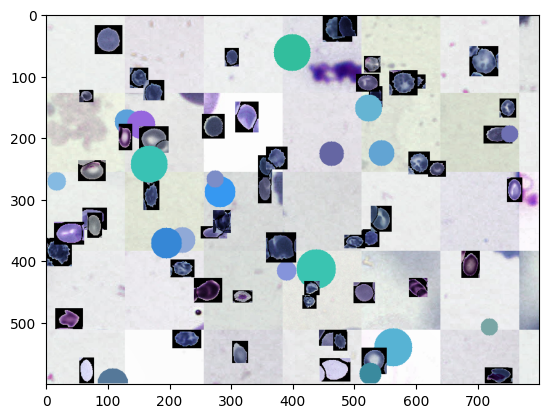

In [13]:
clean_img, _, cells_count, _ = blood_cells_dataset[0]
plt.imshow(cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB))

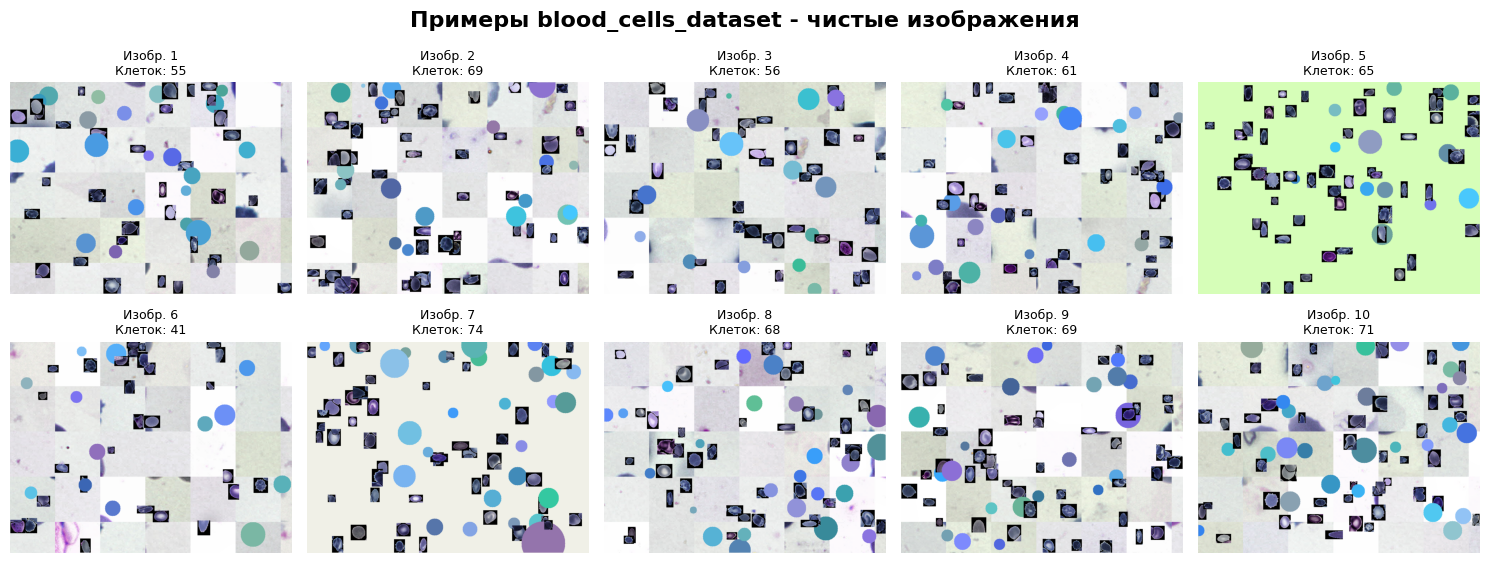

Форма одного изображения: (600, 800, 3)
Тип данных: uint8
Диапазон значений: [1, 255]
Всего изображений в датасете: 100


In [14]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры blood_cells_dataset - чистые изображения", fontsize=16, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    
    clean_img, _, cells_count, _ = blood_cells_dataset[i]

    axes[row, col].imshow(cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f"Изобр. {i+1}\nКлеток: {cells_count}", fontsize=9)
    axes[row, col].axis('off')

    for spine in axes[row, col].spines.values():
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

clean_img, _, _, _ = blood_cells_dataset[0]
print(f"Форма одного изображения: {clean_img.shape}")
print(f"Тип данных: {clean_img.dtype}")
print(f"Диапазон значений: [{clean_img.min()}, {clean_img.max()}]")
print(f"Всего изображений в датасете: {len(blood_cells_dataset)}")

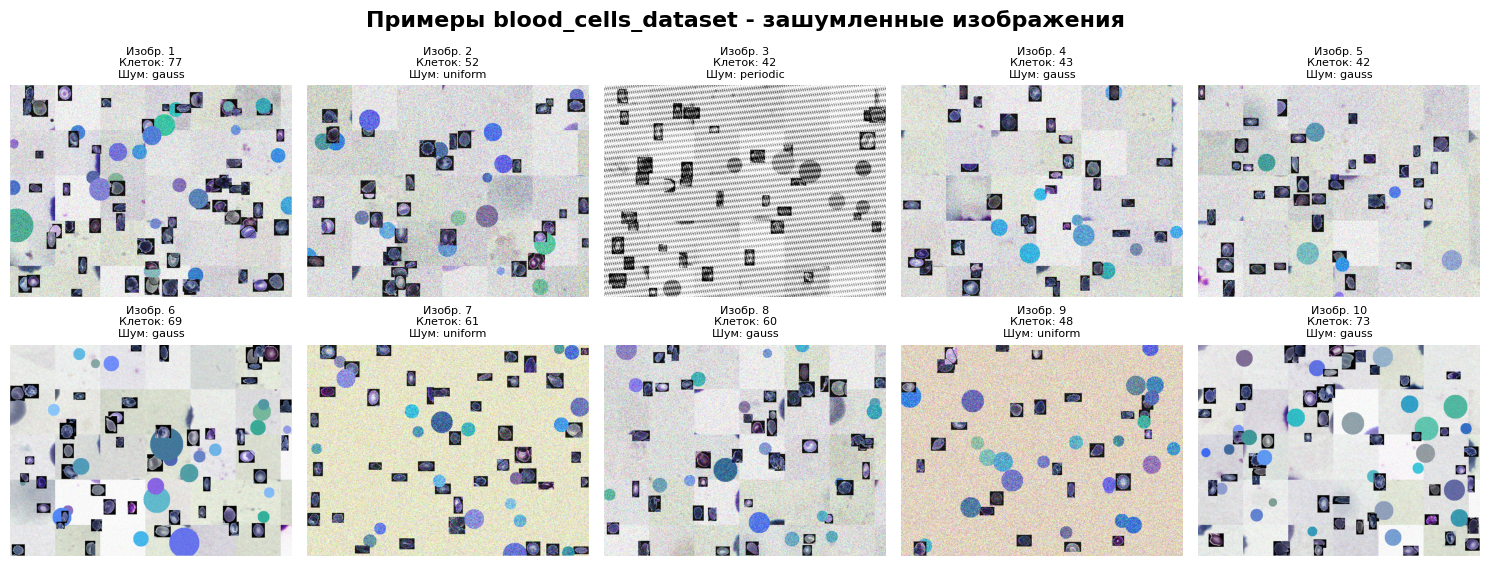

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры blood_cells_dataset - зашумленные изображения", fontsize=16, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5

    _, noisy_img, cells_count, noise_type = blood_cells_dataset[i]
    
    axes[row, col].imshow(cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB) if len(noisy_img.shape)==3 else noisy_img, cmap='gray' if len(noisy_img.shape)==2 else None)
    axes[row, col].set_title(f"Изобр. {i+1}\nКлеток: {cells_count}\nШум: {noise_type}", fontsize=8)
    axes[row, col].axis('off')
    
    for spine in axes[row, col].spines.values():
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

## 3. Удаление шума

In [16]:
filters = [
    {
        "name": "median",
        "func": lambda img, k: cv2.medianBlur(img, k),
        "params_range": [[3, 5, 7, 9]],
    },
    {
        "name": "gaussian",
        "func": lambda img, k, s: cv2.GaussianBlur(img, (k, k), s),
        "params_range": [[3, 5, 7, 9], [0, 1, 2, 3]],
    },
    {
        "name": "bilateral",
        "func": lambda img, d, sc, ss: cv2.bilateralFilter(img, d, sc, ss),
        "params_range": [[5, 7, 9], [50, 75, 100], [50, 75, 100]],
    },
    {
        "name": "nl_means",
        "func": lambda img, h: cv2.fastNlMeansDenoising(img, None, h, 7, 21),
        "params_range": [[10, 20, 30, 40]],
    },
]

def do_denoise_round(img_gray, img_noisy_gray, 
                     filter_dict, res_arr, i):
    img_gray = img_gray.astype(np.uint8)
    img_noisy_gray = img_noisy_gray.astype(np.uint8)
    
    best_mse = mse(img_gray, img_noisy_gray)
    best_ssim = ssim(img_gray, img_noisy_gray)
    best_params_mse = []
    best_params_ssim = []
    found_valid_params = False
    
    for params in itertools.product(*filter_dict["params_range"]):
        try:
            filtered_img_gray = filter_dict["func"](img_noisy_gray, *params)
            
            if filtered_img_gray.shape != img_gray.shape:
                filtered_img_gray = cv2.resize(filtered_img_gray, (img_gray.shape[1], img_gray.shape[0]))
            
            if len(filtered_img_gray.shape) == 3:
                filtered_img_gray = cv2.cvtColor(filtered_img_gray, cv2.COLOR_BGR2GRAY)
            
            curr_mse = mse(img_gray, filtered_img_gray)
            curr_ssim = ssim(img_gray, filtered_img_gray)
            
            if curr_mse < best_mse:
                best_mse = curr_mse
                best_params_mse = list(params)
            
            if curr_ssim > best_ssim:
                best_ssim = curr_ssim
                best_params_ssim = list(params)
            
            found_valid_params = True
            
        except Exception as e:
            continue
    
    res_arr[i] = {
        "best_mse": best_mse,
        "best_ssim": best_ssim,
        "best_params_mse": best_params_mse,
        "best_params_ssim": best_params_ssim,
        "found_valid_params": found_valid_params
    }

## 4. Вейвлет-преобразование Хаара

In [17]:
def haar_transform_1d_forward(data):
    n = len(data)
    result = np.zeros(n)
    half = n // 2
    
    for i in range(half):
        result[i] = (data[2*i] + data[2*i+1]) / np.sqrt(2)
        result[half + i] = (data[2*i] - data[2*i+1]) / np.sqrt(2)
    
    return result


def haar_transform_1d_inverse(data):
    n = len(data)
    result = np.zeros(n)
    half = n // 2
    
    for i in range(half):
        result[2*i] = (data[i] + data[half + i]) / np.sqrt(2)
        result[2*i+1] = (data[i] - data[half + i]) / np.sqrt(2)
    
    return result


def haar_transform_2d_forward(image, level=1):
    h, w = image.shape
    result = image.astype(np.float64).copy()
    
    for lvl in range(level):
        curr_h = h // (2**lvl)
        curr_w = w // (2**lvl)
        
        if curr_h < 2 or curr_w < 2:
            break
        
        for i in range(curr_h):
            row = result[i, :curr_w]
            result[i, :curr_w] = haar_transform_1d_forward(row)
        
        for j in range(curr_w):
            col = result[:curr_h, j]
            result[:curr_h, j] = haar_transform_1d_forward(col)
    
    return result


def haar_transform_2d_inverse(coeffs, level=1):
    h, w = coeffs.shape
    result = coeffs.astype(np.float64).copy()
    
    for lvl in reversed(range(level)):
        curr_h = h // (2**lvl)
        curr_w = w // (2**lvl)
        
        if curr_h < 2 or curr_w < 2:
            break
        
        for j in range(curr_w):
            col = result[:curr_h, j]
            result[:curr_h, j] = haar_transform_1d_inverse(col)
        
        for i in range(curr_h):
            row = result[i, :curr_w]
            result[i, :curr_w] = haar_transform_1d_inverse(row)
    
    return result


def threshold_coefficients(coeffs, threshold_ratio=0.1):
    h, w = coeffs.shape
    result = coeffs.copy()
    
    ll_size = max(1, min(h, w) // 2)
    
    detail_coeffs = []
    for i in range(h):
        for j in range(w):
            if i >= ll_size or j >= ll_size:
                detail_coeffs.append(np.abs(result[i, j]))
    
    if len(detail_coeffs) == 0:
        return result
    
    global_max = np.max(detail_coeffs)
    threshold = global_max * threshold_ratio
    
    for i in range(h):
        for j in range(w):
            if i >= ll_size or j >= ll_size:
                if np.abs(result[i, j]) < threshold:
                    result[i, j] = 0
                else:
                    sign = np.sign(result[i, j])
                    result[i, j] = sign * (np.abs(result[i, j]) - threshold)
    
    return result

## 5. RLE-кодирование

In [18]:
def rle_encode_grayscale(image):
    flat = image.flatten().astype(int)
    encoded = []
    zero_count = 0
    
    for pixel in flat:
        if pixel == 0:
            zero_count += 1
        else:
            if zero_count > 0 or len(encoded) == 0:
                encoded.append((zero_count, pixel))
                zero_count = 0
            else:
                encoded.append((0, pixel))
    
    if zero_count > 0:
        encoded.append((zero_count, 0))
    
    return encoded


def rle_decode(encoded, original_shape):
    flat = []
    for zero_count, value in encoded:
        flat.extend([0] * zero_count)
        flat.append(value)
    
    result = np.array(flat, dtype=np.uint8).reshape(original_shape)
    return result


def save_rle_to_file(encoded, filepath):
    with open(filepath, 'w') as f:
        for zeros, val in encoded:
            f.write(f"{zeros} {val}\n")


def load_rle_from_file(filepath, shape):
    encoded = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                encoded.append((int(parts[0]), int(parts[1])))
    return rle_decode(encoded, shape)

## 6. Функция сжатия

In [19]:
def compress_image_wavelet_rle(image, wavelet_level=2, threshold_ratio=0.1, 
                              output_prefix='compressed'):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    original_size = gray.nbytes
    
    coeffs = haar_transform_2d_forward(gray, level=wavelet_level)
    
    coeffs_thresh = threshold_coefficients(coeffs, threshold_ratio)
    
    reconstructed = haar_transform_2d_inverse(coeffs_thresh, level=wavelet_level)
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    
    encoded = rle_encode_grayscale(reconstructed)
    
    filepath = f"{output_prefix}.txt"
    save_rle_to_file(encoded, filepath)
    compressed_size = os.path.getsize(filepath)
    
    compression_ratio = original_size / compressed_size if compressed_size > 0 else float('inf')
    mse_val = mse(gray, reconstructed)
    ssim_val = ssim(gray, reconstructed)
    
    return {
        'original_size': original_size,
        'compressed_size': compressed_size,
        'compression_ratio': compression_ratio,
        'mse': mse_val,
        'ssim': ssim_val,
        'reconstructed': reconstructed,
        'encoded_length': len(encoded),
        'wavelet_level': wavelet_level,
        'threshold_ratio': threshold_ratio,
        'filepath': filepath
    }

## 7. Оценка

In [20]:
test_images = 100
denoise_results = {}
for f in filters:
    denoise_results[f["name"]] = {
        "gauss": {"best_mse": [], "best_ssim": [], "best_params_mse": [], "best_params_ssim": []},
        "uniform": {"best_mse": [], "best_ssim": [], "best_params_mse": [], "best_params_ssim": []},
        "periodic": {"best_mse": [], "best_ssim": [], "best_params_mse": [], "best_params_ssim": []},
    }

fourier_results = []
compression_results = []

print("Генерация изображений и удаление шума...")
for img_ind in range(test_images):
    sample = blood_cells_dataset[img_ind]
    img_gray = cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY)
    img_noisy = sample[1].astype(np.uint8)
    
    if len(img_noisy.shape) == 3:
        img_noisy_gray = cv2.cvtColor(img_noisy, cv2.COLOR_BGR2GRAY)
    else:
        img_noisy_gray = img_noisy
    
    noise_type = sample[3]
    
    if noise_type == 'periodic':
        denoised_fourier, spectrum, mask = fourier_denoise_periodic(img_noisy, notch_radius=15)
        mse_f = mse(img_gray, denoised_fourier)
        ssim_f = ssim(img_gray, denoised_fourier)
        fourier_results.append({'mse': mse_f, 'ssim': ssim_f, 'noise_type': noise_type})
    
    for f_idx, f in enumerate(filters):
        temp_result = [{}]
        do_denoise_round(img_gray, img_noisy_gray, f, temp_result, 0)
        
        result = temp_result[0]
        if "best_mse" in result:
            if noise_type in denoise_results[f["name"]]:
                denoise_results[f["name"]][noise_type]["best_mse"].append(result["best_mse"])
                denoise_results[f["name"]][noise_type]["best_ssim"].append(result["best_ssim"])
                denoise_results[f["name"]][noise_type]["best_params_mse"].append(result["best_params_mse"])
                denoise_results[f["name"]][noise_type]["best_params_ssim"].append(result["best_params_ssim"])
    
    comp_result = compress_image_wavelet_rle(
        sample[0], 
        wavelet_level=2, 
        threshold_ratio=0.15,
        output_prefix=f'compress_test_{img_ind:03d}'
    )
    compression_results.append(comp_result)
    
    if (img_ind + 1) % 10 == 0:
        print(f"Обработано {img_ind + 1}/{test_images} изображений")
        break

Генерация изображений и удаление шума...
Обработано 10/100 изображений


## 8. Анализ результатов

In [21]:
def get_denoise_results_mean(denoise_results, noise_type):
    print(f"\n{'='*60}")
    print(f"Тип шума: {noise_type}")
    print(f"{'='*60}")
    
    for filter_name, data in denoise_results.items():
        if len(data[noise_type]["best_mse"]) > 0:
            mean_mse = np.mean(data[noise_type]["best_mse"])
            mean_ssim = np.mean(data[noise_type]["best_ssim"])
            
            best_params_mse = data[noise_type]["best_params_mse"]
            best_params_ssim = data[noise_type]["best_params_ssim"]

            print(f"{filter_name:15} mean: mse={mean_mse:.2f}, ssim={mean_ssim:.4f}")

get_denoise_results_mean(denoise_results, "gauss")
get_denoise_results_mean(denoise_results, "uniform")
get_denoise_results_mean(denoise_results, "periodic")

print(f"\n{'='*60}")
print("ЛУЧШИЕ АЛГОРИТМЫ")
print(f"{'='*60}")

for noise_t in ['gauss', 'uniform', 'periodic']:
    ssim_dict = {name: np.mean(data[noise_t]["best_ssim"]) for name, data in denoise_results.items() if len(data[noise_t]["best_ssim"]) > 0}
    if ssim_dict:
        best = max(ssim_dict, key=ssim_dict.get)
        print(f"Лучший для {noise_t} шума: {best} (SSIM={ssim_dict[best]:.4f})")

if fourier_results:
    avg_mse = np.mean([r['mse'] for r in fourier_results])
    avg_ssim = np.mean([r['ssim'] for r in fourier_results])
    print(f"\nФурье-метод для периодического шума: MSE={avg_mse:.2f}, SSIM={avg_ssim:.4f}")

if compression_results:
    ratios = [r['compression_ratio'] for r in compression_results]
    ssim_vals = [r['ssim'] for r in compression_results]
    print(f"\nВейвлет+RLE сжатие: средняя степень {np.mean(ratios):.2f}x, SSIM={np.mean(ssim_vals):.4f}")


Тип шума: gauss
median          mean: mse=125.34, ssim=0.8564
gaussian        mean: mse=171.60, ssim=0.8510
bilateral       mean: mse=80.83, ssim=0.8942
nl_means        mean: mse=78.86, ssim=0.9165

Тип шума: uniform
median          mean: mse=340.27, ssim=0.7423
gaussian        mean: mse=401.65, ssim=0.7845
bilateral       mean: mse=279.22, ssim=0.7315
nl_means        mean: mse=235.23, ssim=0.8803

Тип шума: periodic
median          mean: mse=1203.98, ssim=0.2542
gaussian        mean: mse=1144.52, ssim=0.2794
bilateral       mean: mse=1335.54, ssim=0.2410
nl_means        mean: mse=1810.06, ssim=0.1272

ЛУЧШИЕ АЛГОРИТМЫ
Лучший для gauss шума: nl_means (SSIM=0.9165)
Лучший для uniform шума: nl_means (SSIM=0.8803)
Лучший для periodic шума: gaussian (SSIM=0.2794)

Фурье-метод для периодического шума: MSE=7734.11, SSIM=0.8134

Вейвлет+RLE сжатие: средняя степень 0.15x, SSIM=0.9552


## 9. Визуализация результатов

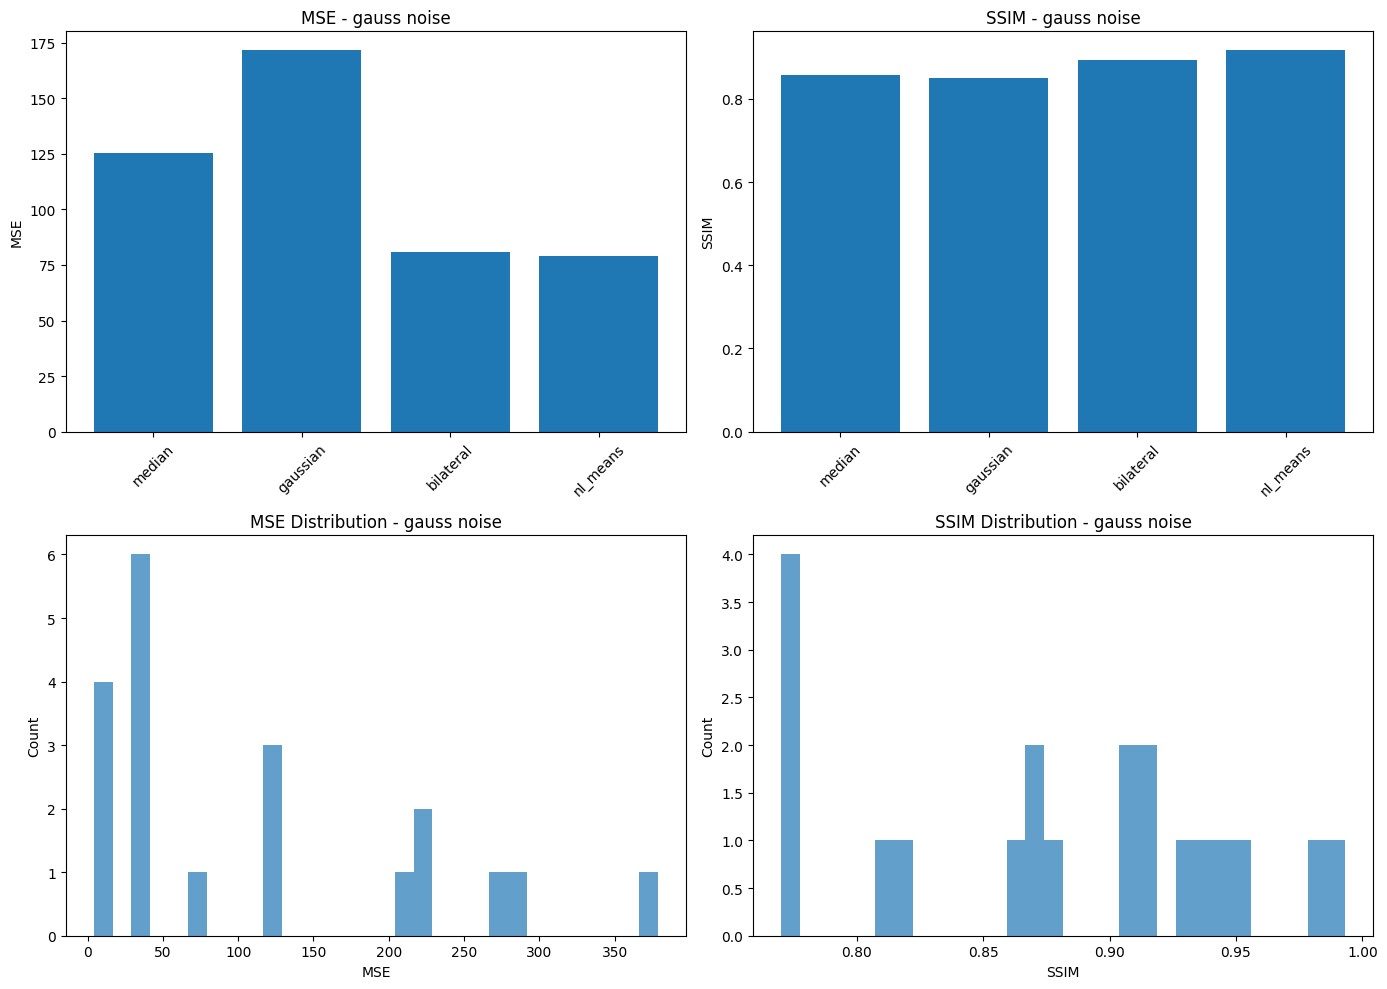

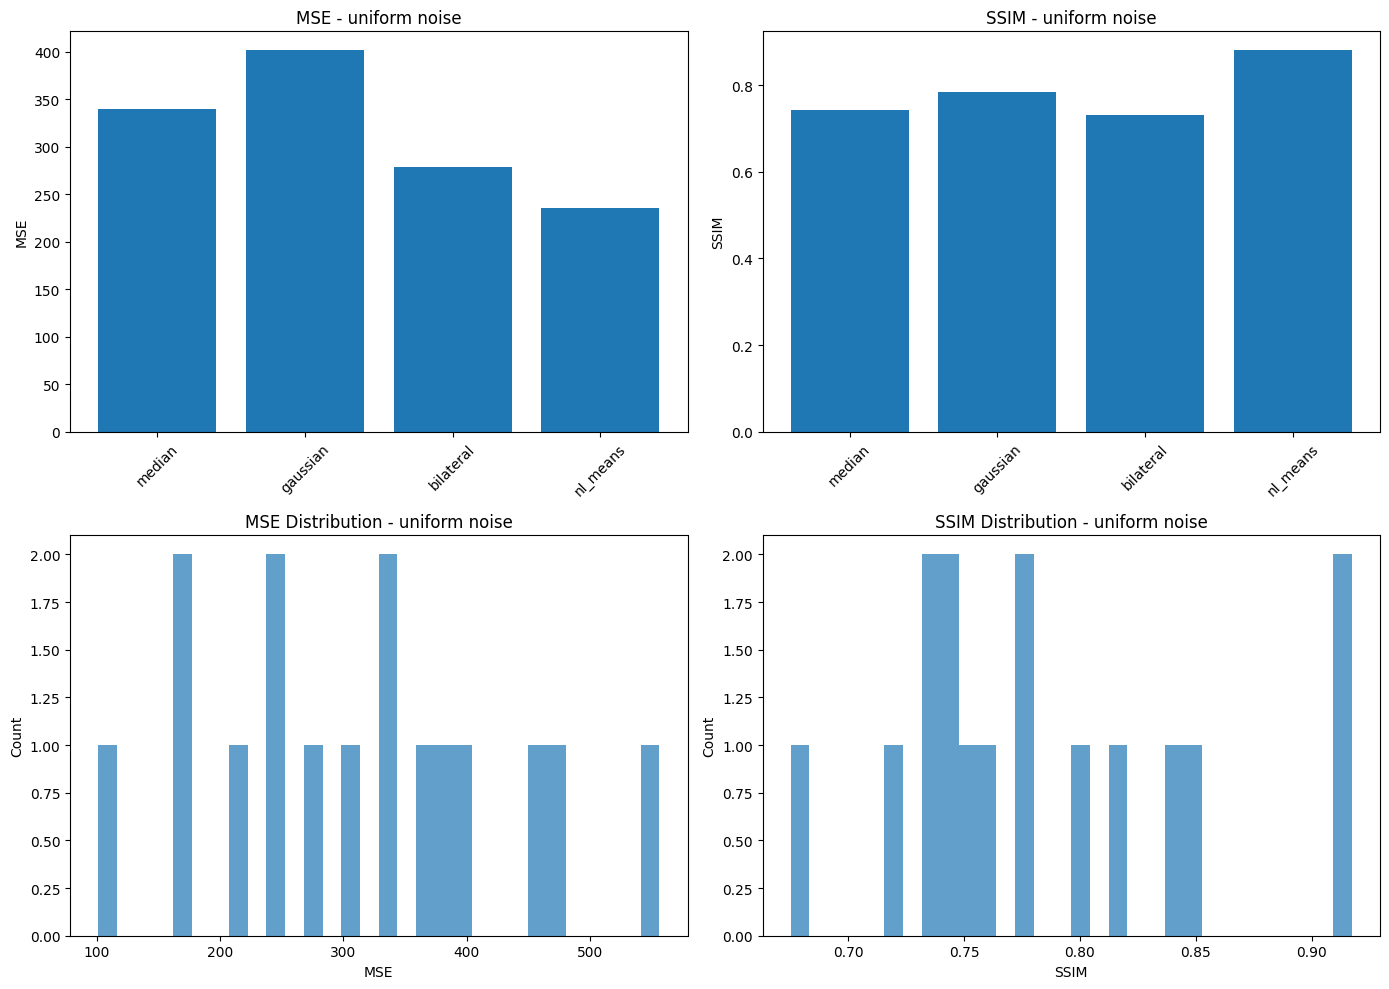

In [ ]:
def plot_denoising_results(denoise_results, noise_type):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    filters_names = list(denoise_results.keys())

    mse_values = [np.mean(denoise_results[f][noise_type]["best_mse"]) for f in filters_names if len(denoise_results[f][noise_type]["best_mse"]) > 0]
    axes[0, 0].bar(range(len(mse_values)), mse_values)
    axes[0, 0].set_xticks(range(len(mse_values)))
    axes[0, 0].set_xticklabels([f for f in filters_names if len(denoise_results[f][noise_type]["best_mse"]) > 0], rotation=45)
    axes[0, 0].set_title(f'MSE - {noise_type} noise')
    axes[0, 0].set_ylabel('MSE')

    ssim_values = [np.mean(denoise_results[f][noise_type]["best_ssim"]) for f in filters_names if len(denoise_results[f][noise_type]["best_ssim"]) > 0]
    axes[0, 1].bar(range(len(ssim_values)), ssim_values)
    axes[0, 1].set_xticks(range(len(ssim_values)))
    axes[0, 1].set_xticklabels([f for f in filters_names if len(denoise_results[f][noise_type]["best_ssim"]) > 0], rotation=45)
    axes[0, 1].set_title(f'SSIM - {noise_type} noise')
    axes[0, 1].set_ylabel('SSIM')

    all_mse = []
    for f in filters_names:
        all_mse.extend(denoise_results[f][noise_type]["best_mse"])
    axes[1, 0].hist(all_mse, bins=30, alpha=0.7)
    axes[1, 0].set_title(f'MSE Distribution - {noise_type} noise')
    axes[1, 0].set_xlabel('MSE')
    axes[1, 0].set_ylabel('Count')
    
    all_ssim = []
    for f in filters_names:
        all_ssim.extend(denoise_results[f][noise_type]["best_ssim"])
    axes[1, 1].hist(all_ssim, bins=30, alpha=0.7)
    axes[1, 1].set_title(f'SSIM Distribution - {noise_type} noise')
    axes[1, 1].set_xlabel('SSIM')
    axes[1, 1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()

plot_denoising_results(denoise_results, "gauss")
plot_denoising_results(denoise_results, "uniform")

In [ ]:
sample_idx = 0
for i in range(len(blood_cells_dataset)):
    _, _, _, nt = blood_cells_dataset[i]
    if nt == 'periodic':
        sample_idx = i
        break

sample = blood_cells_dataset[sample_idx]
clean_img = sample[0].astype(np.uint8)
noisy_img = sample[1].astype(np.uint8)
noise_type = sample[3]

if noise_type == 'periodic':
    denoised_fourier, spectrum, mask = fourier_denoise_periodic(noisy_img)
    clean_gray = cv2.cvtColor(clean_img, cv2.COLOR_BGR2GRAY)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes[0,0].imshow(clean_gray, cmap='gray')
    axes[0,0].set_title('Clean')
    axes[0,0].axis('off')
    
    axes[0,1].imshow(cv2.cvtColor(noisy_img, cv2.COLOR_BGR2GRAY), cmap='gray')
    axes[0,1].set_title(f'Noisy ({noise_type})')
    axes[0,1].axis('off')
    
    axes[0,2].imshow(denoised_fourier, cmap='gray')
    axes[0,2].set_title('Denoised (Fourier)')
    axes[0,2].axis('off')
    
    axes[1,0].imshow(spectrum, cmap='gray')
    axes[1,0].set_title('Spectrum')
    axes[1,0].axis('off')
    
    axes[1,1].imshow(mask, cmap='gray')
    axes[1,1].set_title('Notch Mask')
    axes[1,1].axis('off')
    
    diff = np.abs(clean_gray.astype(float) - denoised_fourier.astype(float))
    axes[1,2].imshow(diff, cmap='hot')
    axes[1,2].set_title('Difference')
    axes[1,2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Fourier: MSE={mse(clean_gray, denoised_fourier):.2f}, SSIM={ssim(clean_gray, denoised_fourier):.4f}")

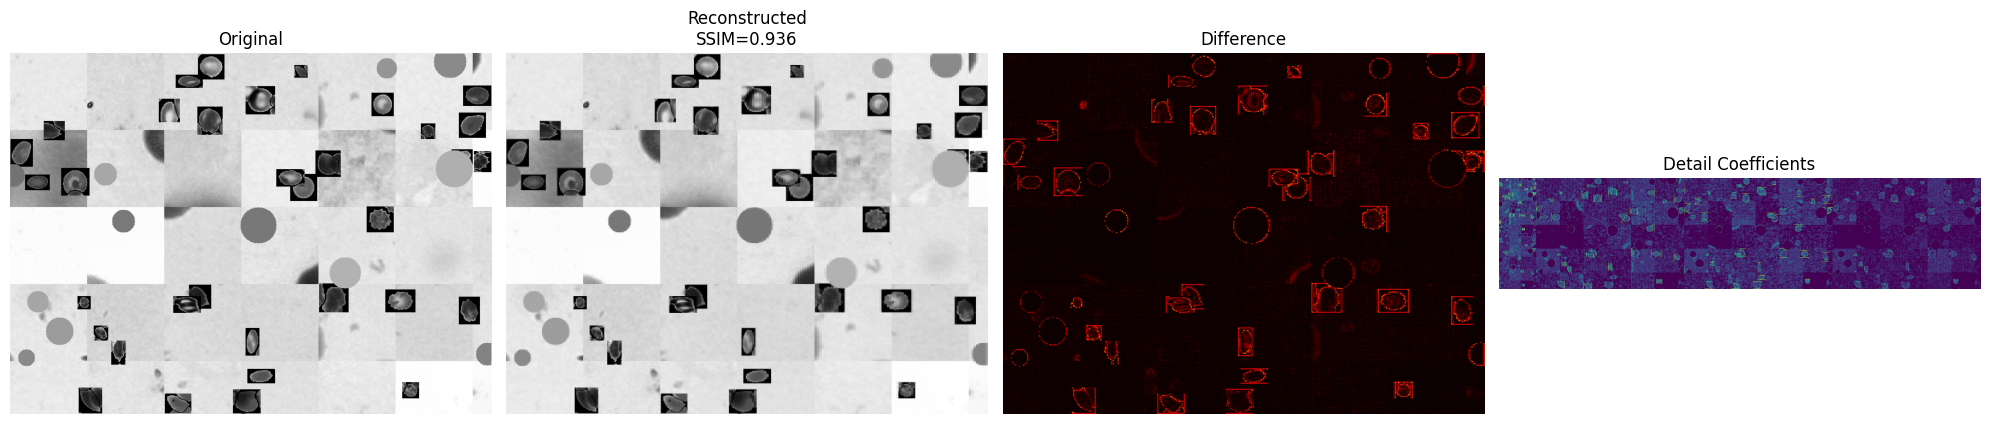

Compression: 0.15x, 480000 -> 3250881 bytes, SSIM=0.9358


In [ ]:
sample_idx = 0
clean_sample, _, _, _ = blood_cells_dataset[sample_idx]
comp_result = compress_image_wavelet_rle(clean_sample, wavelet_level=2, threshold_ratio=0.15, output_prefix='example_compress')

gray_orig = cv2.cvtColor(clean_sample, cv2.COLOR_BGR2GRAY) if len(clean_sample.shape)==3 else clean_sample
reconstructed = comp_result['reconstructed']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(gray_orig, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(reconstructed, cmap='gray')
axes[1].set_title(f'Reconstructed\nSSIM={comp_result["ssim"]:.3f}')
axes[1].axis('off')

diff = np.abs(gray_orig.astype(float) - reconstructed.astype(float))
axes[2].imshow(diff, cmap='hot')
axes[2].set_title('Difference')
axes[2].axis('off')

coeffs = haar_transform_2d_forward(gray_orig, level=2)
ll_size = coeffs.shape[0] // 2
lh = coeffs[:ll_size, ll_size:]
hl = coeffs[ll_size:, :ll_size]
hh = coeffs[ll_size:, ll_size:]
combined = np.hstack([np.log(np.abs(lh)+1), np.log(np.abs(hl)+1), np.log(np.abs(hh)+1)])
axes[3].imshow(combined, cmap='viridis')
axes[3].set_title('Detail Coefficients')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Compression: {comp_result['compression_ratio']:.2f}x, {comp_result['original_size']} -> {comp_result['compressed_size']} bytes, SSIM={comp_result['ssim']:.4f}")